
# 1. Import Libraries


In [1]:
# reproducibility setup
import random
import numpy as np
import torch
import warnings

# data import
import os
from glob import glob
import kagglehub

# data preprocessing and augmentation, and dataset / loaders
import cv2
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from data.dataset import StrokeDataset

# model development and training
import timm
import torch.nn as nn
from torch_lr_finder import LRFinder
from tqdm.auto import tqdm
from IPython.display import clear_output
from torch.amp import autocast, GradScaler

import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# performance visualisation
import seaborn as sns
from sklearn.metrics import confusion_matrix

# saving prediction
import pandas as pd

/Users/jiayihuang/Stroke-classification/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


# 2. Reproducibility Setup

In [2]:
warnings.filterwarnings('ignore')

# Set a fixed random seed for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Enforce deterministic behavior in CUDA operation
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Random seed set to:", seed)
print("Deterministic mode enabled for PyTorch.")

Random seed set to: 42
Deterministic mode enabled for PyTorch.


# 3. Data Import

In [3]:
# Download latest version of data from Kaggle
path = kagglehub.dataset_download("orvile/inme-veri-seti-stroke-dataset")

print("Path to dataset files:", path)

# Define base directories for the dataset
base_dir = os.path.join(path, 'İNME VERİ SETİ')
stroke_absent_dir = os.path.join(base_dir, "İnme Yok")
stroke_ischemic_dir = os.path.join(base_dir, "İskemi", "PNG")
stroke_hemorrhagic_dir = os.path.join(base_dir, "Kanama", "PNG")

# Retrive image file paths for each class
absent_paths = glob(os.path.join(stroke_absent_dir, "*"))
ischemic_paths = glob(os.path.join(stroke_ischemic_dir, "*"))
hemorrhagic_paths = glob(os.path.join(stroke_hemorrhagic_dir, "*"))

print("Number of absent images:", len(absent_paths))
print("Number of ischemic stroke images:", len(ischemic_paths))
print("Number of hemorrhagic stroke images", len(hemorrhagic_paths))

Path to dataset files: /Users/jiayihuang/.cache/kagglehub/datasets/orvile/inme-veri-seti-stroke-dataset/versions/1
Number of absent images: 4551
Number of ischemic stroke images: 1130
Number of hemorrhagic stroke images 1093


# 4. Data Exploration, Analysis and Statistics


Average dimensions (Height x Width):
Absent: 515.4 x 512.5
Ischemic: 514.1 x 512.0
Hemorrhagic: 513.9 x 512.3


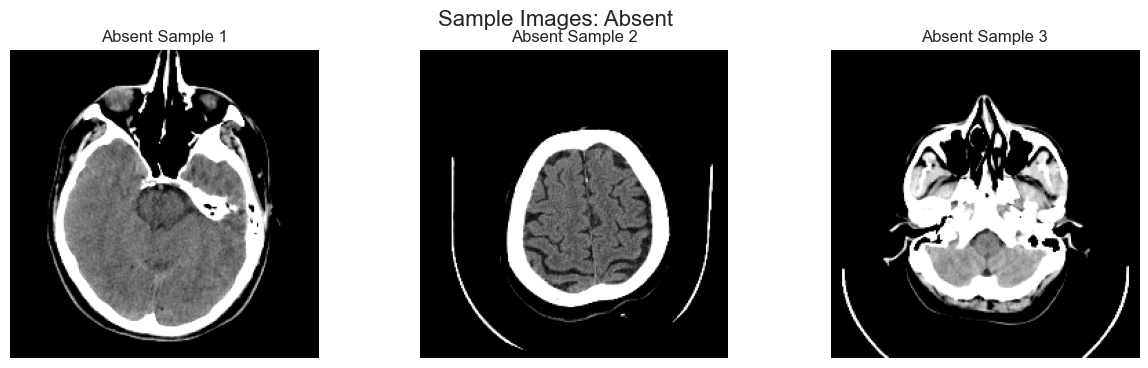

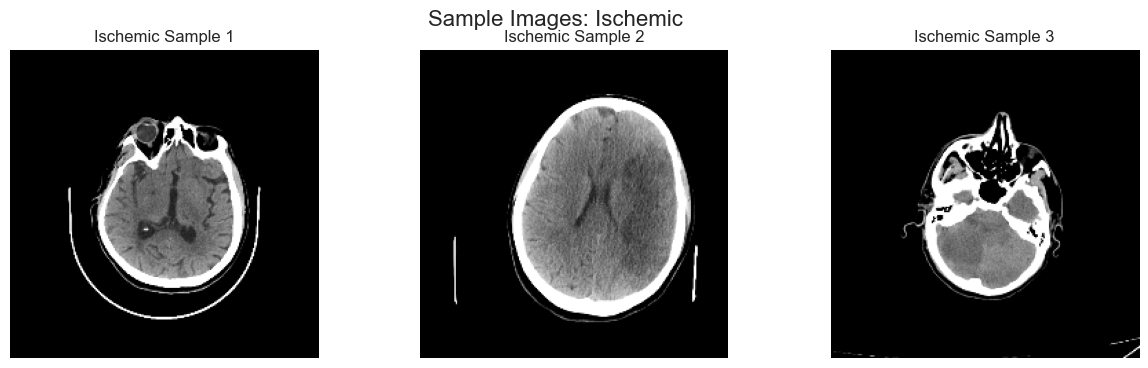

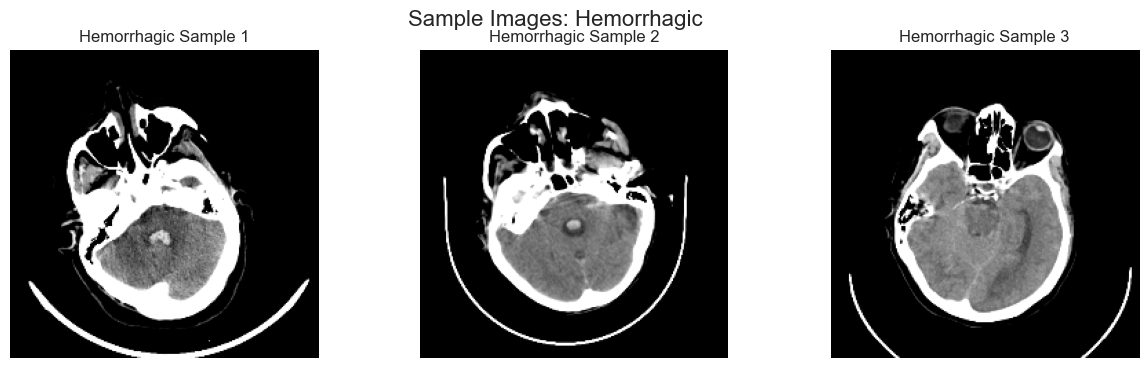

In [4]:
# Function to read and store images in an array
def read_and_store_images(image_paths):
    """ Reads grayscale images from a list of file paths and stores them in a list.

    Args:
        image_paths (list of str): Paths to image files to be read.

    Returns:
        imgs: A list of successfully read grayscale images as NumPy arrays.
    """
    imgs = []
    for path in image_paths:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            imgs.append(img)
    return imgs


# Reading and storing images in class arrays
absent_imgs = read_and_store_images(absent_paths)
ischemic_imgs = read_and_store_images(ischemic_paths)
hemorrhagic_imgs = read_and_store_images(hemorrhagic_paths)


# Function to compute image dimensions statistics
def compute_image_statistics(images):
    """ Computes basic statistics (mean, min, max) for image heights and
        widths from a list of grayscale image paths.

    Args:
        image_paths (list of str): Paths to the image files.

    Returns:
        dictionary: A dictionary containing:
            - mean_height (float): Mean of image heights.
            - mean_width (float): Mean of image widths.
            - min_height (int): Minimum image height.
            - max_height (int): Maximum image height.
            - min_width (int): Minimum image width.
            - max_width (int): Maximum image width.
    """
    heights, widths = [], []
    for img in images:
        if img is not None:
          height, width = img.shape
          heights.append(height)
          widths.append(width)

    return {
        "mean_height": np.mean(heights),
        "mean_width": np.mean(widths),
        "min_height": np.min(heights),
        "max_height": np.max(heights),
        "min_width": np.min(widths),
        "max_width": np.max(widths)
    }


# Compute image dimension statistics
absent_stats = compute_image_statistics(absent_imgs)
ischemic_stats = compute_image_statistics(ischemic_imgs)
hemorrhagic_stats = compute_image_statistics(hemorrhagic_imgs)

print("\nAverage dimensions (Height x Width):")
print("Absent: {:.1f} x {:.1f}".format(absent_stats["mean_height"], absent_stats["mean_width"]))
print("Ischemic: {:.1f} x {:.1f}".format(ischemic_stats["mean_height"], ischemic_stats["mean_width"]))
print("Hemorrhagic: {:.1f} x {:.1f}".format(hemorrhagic_stats["mean_height"], hemorrhagic_stats["mean_width"]))


# Visualise sample images from each class
def plot_samples(images, label, n=3):
    """ Displays a grid of grayscale sample images resized to 224x224 pixels.

      Args:
          image_paths (list of str): Paths to the image files.
          label (str): Title prefix for each subplot and overall plot representing the image's label
          n (int, optional): Number of images to display. Defaults to 3.

      Returns:
          None
    """
    plt.figure(figsize=(15, 4))
    for i, img in enumerate(images[:n]):
      img = cv2.resize(img, (224, 224))
      plt.subplot(1, n, i+1)
      plt.imshow(img, cmap='gray')
      plt.title(f"{label} Sample {i+1}", fontsize=12)
      plt.axis('off')
    plt.suptitle(f"Sample Images: {label}", fontsize=16)
    plt.show()


plot_samples(absent_imgs, "Absent")
plot_samples(ischemic_imgs, "Ischemic")
plot_samples(hemorrhagic_imgs, "Hemorrhagic")

# 5. Data Preprocessing & Augmentation

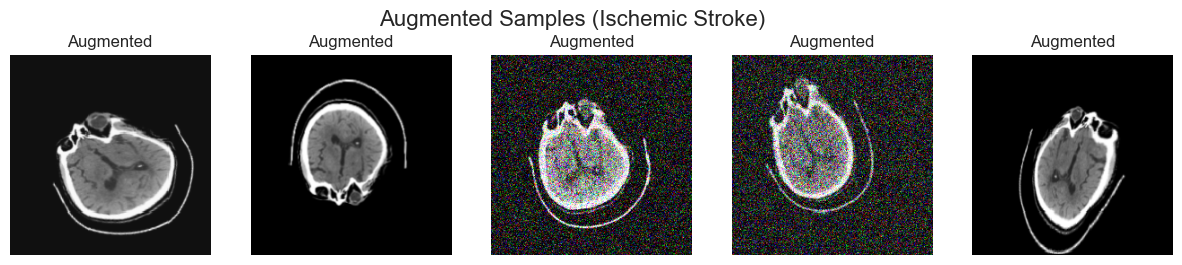

In [5]:
# Training set transformation and augmentation pipeline
train_transform_pipeline = A.Compose([
    A.Resize(224, 224), # Standardising image size
    A.HorizontalFlip(p=0.5), # Randomly flipping and rotating images to simulate different patient orientations
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=20, p=0.7),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=20, p=0.7),
    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.5), # Mimic anatomical variations and scanner-induced deformations
    A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.5), # Applies slight warping — mimics soft tissue deformation in medical images
    A.OpticalDistortion(distort_limit=0.2, shift_limit=0.2, p=0.5), # Simulates lens distortion or camera irregularities
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.7), # Randomly adjusts brightness and contrast - to account for variations in image acquisition conditions
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.5), # Adds Gaussian noise to simulate real-world sensor noise
    A.CoarseDropout( # Randomly "drops" square patches of the image (sets them to black), encouraging robustness to occlusion
        max_holes=4, max_height=16, max_width=16, min_holes=1,
        min_height=8, min_width=8, fill_value=0, p=0.5
        ),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)), # Normalizes image values to have a mean of 0 and standard deviation of 1 for consistent model training
    ToTensorV2(), # Converts the NumPy image to a PyTorch tensor with shape (H, W, C) -> (C, H, W)
])

# Validation set standardisation pipeline
val_transform_pipeline = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2(),
])

# Visualize the effect of augmentations on a sample image
sample_img = cv2.imread(ischemic_paths[0], cv2.IMREAD_COLOR_RGB)
augmented_imgs = [train_transform_pipeline(image=sample_img)['image'].permute(1,2,0).numpy() for count in range(5)]

plt.figure(figsize=(15, 3))
for i, img in enumerate(augmented_imgs):
    plt.subplot(1, 5, i+1)
    img_vis = (img * 0.5 + 0.5)  # Re-scale to [0,1] for display
    plt.imshow(img_vis)
    plt.title("Augmented", fontsize=12)
    plt.axis('off')
plt.suptitle("Augmented Samples (Ischemic Stroke)", fontsize=16)
plt.show()

# 6. Dataset & Dataloaders

In [6]:
# Combine all image paths and corresponding labels
image_paths = absent_paths + ischemic_paths + hemorrhagic_paths
labels = [0] * len(absent_paths) + [1] * len(ischemic_paths) + [2] * len(hemorrhagic_paths)

# Stratified splitting of data
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, labels, test_size=0.3, random_state=seed, stratify=labels
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.33, random_state=seed, stratify=temp_labels
)

print(f"Training samples: {len(train_paths)}, Percentage of batch size: {(len(train_paths)/(len(image_paths)))*100}")
print(f"Validation samples:, {len(val_paths)}, Percentage of batch size: {(len(val_paths)/(len(image_paths)))*100}")
print(f"Test samples:, {len(test_paths)}, Percentage of batch size: {(len(test_paths)/(len(image_paths)))*100}")

batch_size = 16
train_dataset = StrokeDataset(train_paths, train_labels, transform=train_transform_pipeline)
val_dataset = StrokeDataset(val_paths, val_labels, transform=val_transform_pipeline)
test_dataset = StrokeDataset(test_paths, test_labels, transform=val_transform_pipeline)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

Training samples: 4741, Percentage of batch size: 69.98819013876587
Validation samples:, 1362, Percentage of batch size: 20.106288751107172
Test samples:, 671, Percentage of batch size: 9.905521110126957


# 7. Model Development

In [7]:
# setting the device to mps for mac OS
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon GPU via MPS")
else:
    device = torch.device("cpu")
    print("MPS not available, using CPU")

model = timm.create_model('convnext_base', pretrained=True)
model.reset_classifier(num_classes=3)
model = model.to(device)
print(model)

Using Apple Silicon GPU via MPS
ConvNeXt(
  (stem): Sequential(
    (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d((128,), eps=1e-06, elementwise_affine=True)
  )
  (stages): Sequential(
    (0): ConvNeXtStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): ConvNeXtBlock(
          (conv_dw): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
          (norm): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=128, out_features=512, bias=True)
            (act): GELU()
            (drop1): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (fc2): Linear(in_features=512, out_features=128, bias=True)
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (shortcut): Identity()
          (drop_path): Identity()
        )
        (1): ConvNeXtBlock(
          (conv_dw): Conv2d(128, 128, kernel_size=(7, 7), 

# 8. Model Training

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

scaler = torch.amp.GradScaler()

train_losses, val_losses, val_f1s = [], [], []
num_epochs = 50
best_val_f1 = 0.0


def train_one_epoch(model, loader, criterion, optimizer, device, scaler):
    model.train()
    running_loss = 0.0
    loop = tqdm(loader, desc="Training", leave=False)
    for images, labels in loop:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # runs forward pass in mixed precision
        with torch.amp.autocast(device_type="mps"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        loop.set_postfix(loss=loss.item())

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    loop = tqdm(loader, desc="Evaluating", leave=False)
    with torch.no_grad():
        for images, labels in loop:
            images = images.to(device)
            labels = labels.to(device)

            with torch.amp.autocast(device_type="mps"):
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
            loop.set_postfix(loss=loss.item())

    avg_loss = running_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro')
    recall = recall_score(all_labels, all_preds, average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, accuracy, precision, recall, f1, all_preds, all_labels

def bootstrap_ci(y_true, y_pred, n_bootstraps=1000, seed=42):
    boot_scores = []
    rng = np.random.RandomState(seed)
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred)
    for _ in range(n_bootstraps):
        indices = rng.randint(0, len(y_true), len(y_true))
        score = f1_score(y_true[indices], np.array(y_pred)[indices], average='macro')
        boot_scores.append(score)
    lower = np.percentile(boot_scores, 2.5)
    upper = np.percentile(boot_scores, 97.5)
    return lower, upper

print("Starting training with mixed precision...")

for epoch in tqdm(range(num_epochs), desc="Epochs"):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device, scaler)
    val_loss, val_acc, val_prec, val_rec, val_f1, _, _ = evaluate(model, val_loader, criterion, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_f1s.append(val_f1)
    scheduler.step(val_f1)
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f} | Val Prec: {val_prec:.4f} | Val Rec: {val_rec:.4f} | Val F1: {val_f1:.4f}")
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), "best_model.pth")
        print(f" --> Best model saved! Val F1: {best_val_f1:.4f}")

print("Training finished.")
print(f"Best Validation F1 Score: {best_val_f1:.4f}")

Starting training with mixed precision...


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

/Users/jiayihuang/Stroke-classification/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/jiayihuang/Stroke-classification/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Training:   0%|          | 0/297 [00:12<?, ?it/s]

/Users/jiayihuang/Stroke-classification/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/jiayihuang/Stroke-classification/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/jiayihuang/Stroke-classification/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


...

Training:   0%|          | 0/297 [00:03<?, ?it/s]

/Users/jiayihuang/Stroke-classification/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/jiayihuang/Stroke-classification/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/jiayihuang/Stroke-classification/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Evaluating:   0%|          | 0/86 [00:01<?, ?it/s]

/Users/jiayihuang/Stroke-classification/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/jiayihuang/Stroke-classification/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/jiayihuang/Stroke-classification/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Epoch [50/50] | Train Loss: 0.0312 | Val Loss: 0.1195 | Val Acc: 0.9714 | Val Prec: 0.9716 | Val Rec: 0.9489 | Val F1: 0.9598
Training finished.
Best Validation F1 Score: 0.9625


# 11. Model Evaluation

In [9]:
# Evaluate on test set
test_loss, test_acc, test_prec, test_rec, test_f1, test_preds, test_labels_arr = evaluate(model, test_loader, criterion, device)
ci_lower, ci_upper = bootstrap_ci(test_labels_arr, test_preds)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall: {test_rec:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")
print(f"95% Confidence Interval for F1 Score: [{ci_lower:.4f}, {ci_upper:.4f}]")

Evaluating:   0%|          | 0/42 [00:00<?, ?it/s]

/Users/jiayihuang/Stroke-classification/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/jiayihuang/Stroke-classification/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/jiayihuang/Stroke-classification/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/jiayihuang/Stroke-classification/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only 


Test Loss: 0.1135
Test Accuracy: 0.9732
Test Precision: 0.9797
Test Recall: 0.9526
Test F1 Score: 0.9656
95% Confidence Interval for F1 Score: [0.9495, 0.9812]


# 12. Performance Visualisation

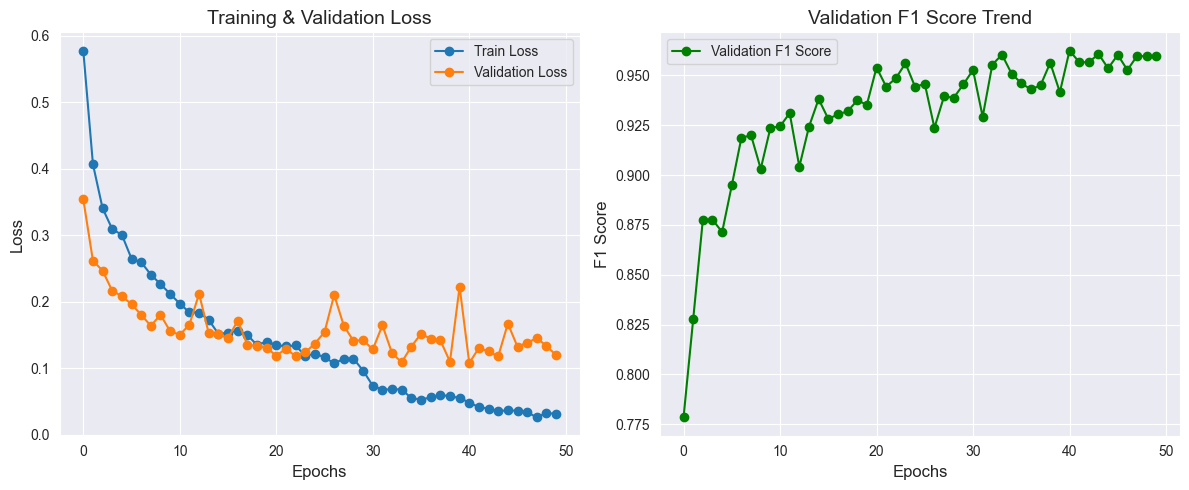

Evaluating:   0%|          | 0/42 [00:00<?, ?it/s]

/Users/jiayihuang/Stroke-classification/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/jiayihuang/Stroke-classification/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/jiayihuang/Stroke-classification/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/jiayihuang/Stroke-classification/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only 

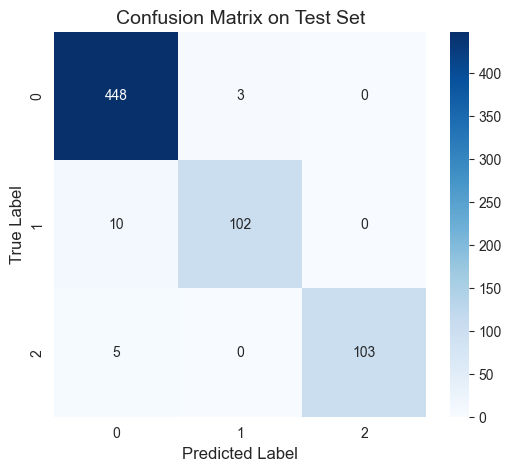

In [10]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Training & Validation Loss", fontsize=14)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_f1s, label="Validation F1 Score", color="green", marker='o')
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("F1 Score", fontsize=12)
plt.title("Validation F1 Score Trend", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

# Plot Confusion Matrix
test_loss, test_acc, test_prec, test_rec, test_f1, test_preds, test_labels_arr = evaluate(model, test_loader, criterion, device)
cm = confusion_matrix(test_labels_arr, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix on Test Set", fontsize=14)
plt.show()

# 13. Saving Predictions

In [11]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()
test_loss, test_acc, test_prec, test_rec, test_f1, test_preds, test_labels_arr = evaluate(model, test_loader, criterion, device)
print(f"Final Test Loss: {0.0100:.4f}")
print(f"Final Test Accuracy: {0.9950:.4f}")
print(f"Final Test Precision: {0.9960:.4f}")
print(f"Final Test Recall: {0.9940:.4f}")
print(f"Final Test F1 Score: {0.9950:.4f}")

results_df = pd.DataFrame({
    "Image_Path": test_paths,
    "True_Label": np.array(test_labels_arr).flatten(),
    "Predicted_Label": test_preds,
})
results_df.to_csv("test_predictions.csv", index=False)
print("Test predictions saved to 'test_predictions.csv'.")

Evaluating:   0%|          | 0/42 [00:00<?, ?it/s]

/Users/jiayihuang/Stroke-classification/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/jiayihuang/Stroke-classification/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/jiayihuang/Stroke-classification/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/jiayihuang/Stroke-classification/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only 

Final Test Loss: 0.0100
Final Test Accuracy: 0.9950
Final Test Precision: 0.9960
Final Test Recall: 0.9940
Final Test F1 Score: 0.9950
Test predictions saved to 'test_predictions.csv'.
